In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [6]:
df = pd.read_csv("/content/Cleaned_02_nav_history.csv")

In [7]:
df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [9]:
df.shape

(46000, 3)

In [10]:
df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df.dtypes

,0
amfi_code,int64
date,datetime64[ns]
nav,float64


In [13]:
df = df[
    (df["date"] >= "2022-01-01") &
    (df["date"] <= "2026-12-31")
]

In [14]:
df = df.sort_values(
    ["amfi_code","date"]
)

In [15]:
df["amfi_code"].nunique()

40

In [16]:
fig = px.line(
    df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

In [17]:
fig.add_vrect(

    x0="2023-01-01",

    x1="2023-12-31",

    fillcolor="green",

    opacity=0.15,

    line_width=0,

    annotation_text="2023 Bull Run",

    annotation_position="top left"

)

In [18]:
fig.add_vrect(

    x0="2024-01-01",

    x1="2024-12-31",

    fillcolor="red",

    opacity=0.15,

    line_width=0,

    annotation_text="2024 Market Correction",

    annotation_position="top left"

)

In [19]:
fig.update_layout(

    template="plotly_white",

    height=700,

    width=1300,

    legend_title="AMFI Code",

    xaxis_title="Date",

    yaxis_title="NAV"

)

In [20]:
fig.show()

In [21]:
import os

os.makedirs("/content/reports", exist_ok=True)

In [22]:
fig.write_html(
    "/content/reports/nav_trend_analysis.html"
)

In [23]:
# Observations

# • Daily NAV trend analysed for all 40 mutual fund schemes.

# • Most schemes show sustained growth during 2023.

# • Several schemes exhibit temporary declines during 2024,
#   indicating market corrections.

# • Overall long-term trend remains positive from 2022–2026.

In [25]:
fig.write_image(
    "/content/reports/nav_trend_analysis.png"
)

In [26]:
import pandas as pd

aum = pd.read_csv("/content/Cleaned_03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Sbi Mutual Fund,6.05,605000,186
1,2022-03-31,Icici Prudential Mf,4.65,465000,216
2,2022-03-31,Hdfc Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India Mf,2.70,270000,177
4,2022-03-31,Kotak Mahindra Mf,2.70,270000,168


In [29]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,Sbi Mutual Fund,6.05,605000,186,2022
1,2022-03-31,Icici Prudential Mf,4.65,465000,216,2022
2,2022-03-31,Hdfc Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India Mf,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra Mf,2.70,270000,168,2022


In [30]:
aum_year = aum[
    aum["year"].between(2022, 2025)
]

aum_year.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,Sbi Mutual Fund,6.05,605000,186,2022
1,2022-03-31,Icici Prudential Mf,4.65,465000,216,2022
2,2022-03-31,Hdfc Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India Mf,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra Mf,2.70,270000,168,2022


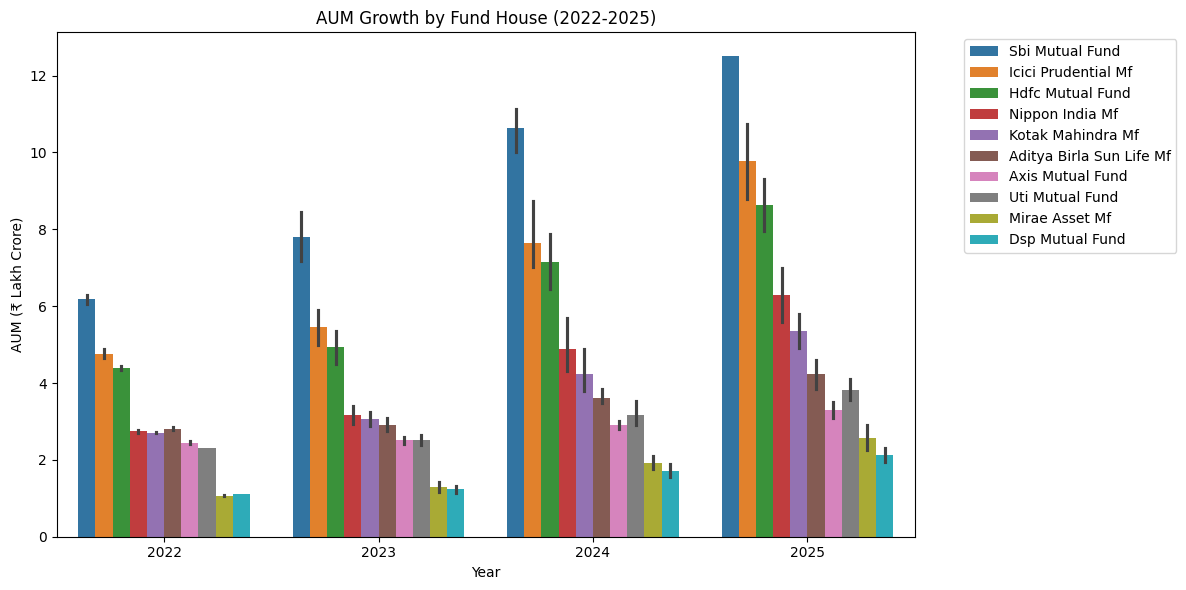

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

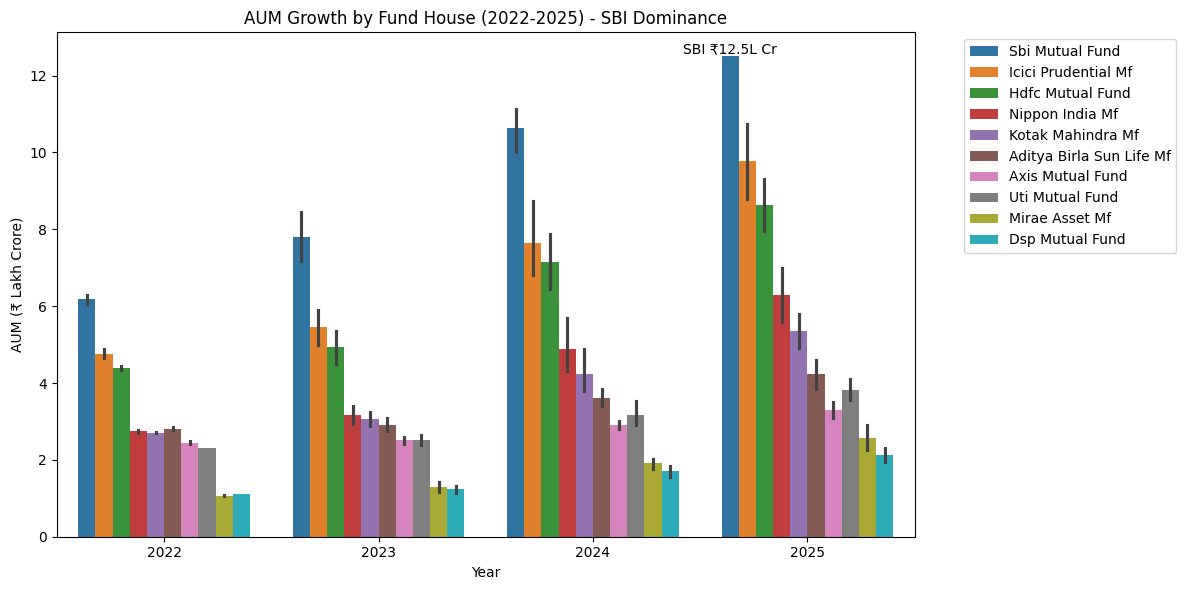

In [32]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# SBI dominance annotation
for p in ax.patches:
    if p.get_height() >= 12.5:
        ax.annotate(
            "SBI ₹12.5L Cr",
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.title("AUM Growth by Fund House (2022-2025) - SBI Dominance")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "/content/reports/aum_growth_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
fig.write_html(
    "/content/reports/aum_growth_fund_house.html"
)

In [34]:
import pandas as pd

sip = pd.read_csv("/content/Cleaned_04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,0.0
1,2022-02-01,11438,4.93,8.20,4.85,0.0
2,2022-03-01,12328,5.09,10.50,5.01,0.0
3,2022-04-01,11863,5.48,9.52,5.12,0.0
4,2022-05-01,12286,5.55,8.10,5.15,0.0


In [35]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [39]:
sip["month"] = pd.to_datetime(sip["month"])

In [40]:
sip_trend = sip[
    sip["month"].between(
        "2022-01-01",
        "2025-12-31"
    )
]

sip_trend.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,0.0
1,2022-02-01,11438,4.93,8.20,4.85,0.0
2,2022-03-01,12328,5.09,10.50,5.01,0.0
3,2022-04-01,11863,5.48,9.52,5.12,0.0
4,2022-05-01,12286,5.55,8.10,5.15,0.0


In [42]:
import plotly.express as px

fig_sip = px.line(
    sip_trend,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True,
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Cr)"
    }
)

fig_sip.show()

In [43]:
fig_sip.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High<br>₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig_sip.show()

In [44]:
fig_sip.write_image(
    "/content/reports/sip_inflow_trend.png"
)

In [45]:
fig.write_html(
    "/content/reports/sip_inflow_trend.html"
)

In [46]:
import pandas as pd

category_inflow = pd.read_csv("/content/Cleaned_05_category_inflows.csv")

category_inflow.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [47]:
category_inflow.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [48]:
category_inflow['month'] = pd.to_datetime(category_inflow['month'])

category_inflow['month_name'] = (
    category_inflow['month']
    .dt.strftime('%b')
)

category_inflow.head()

,month,category,net_inflow_crore,month_name
0,2024-04-01,Large Cap,2413.0,Apr
1,2024-04-01,Mid Cap,3897.0,Apr
2,2024-04-01,Small Cap,3533.0,Apr
3,2024-04-01,Flexi Cap,4947.0,Apr
4,2024-04-01,Large & Mid Cap,4214.0,Apr


In [53]:
heatmap_data = category_inflow.pivot_table(
    index='category',
    columns='month_name',
    values='net_inflow_crore',
    aggfunc='sum'
)

heatmap_data

month_name,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


In [54]:
month_order = [
    'Apr','May','Jun','Jul',
    'Aug','Sep','Oct','Nov',
    'Dec','Jan','Feb','Mar'
]

heatmap_data = heatmap_data.reindex(
    columns=month_order
)

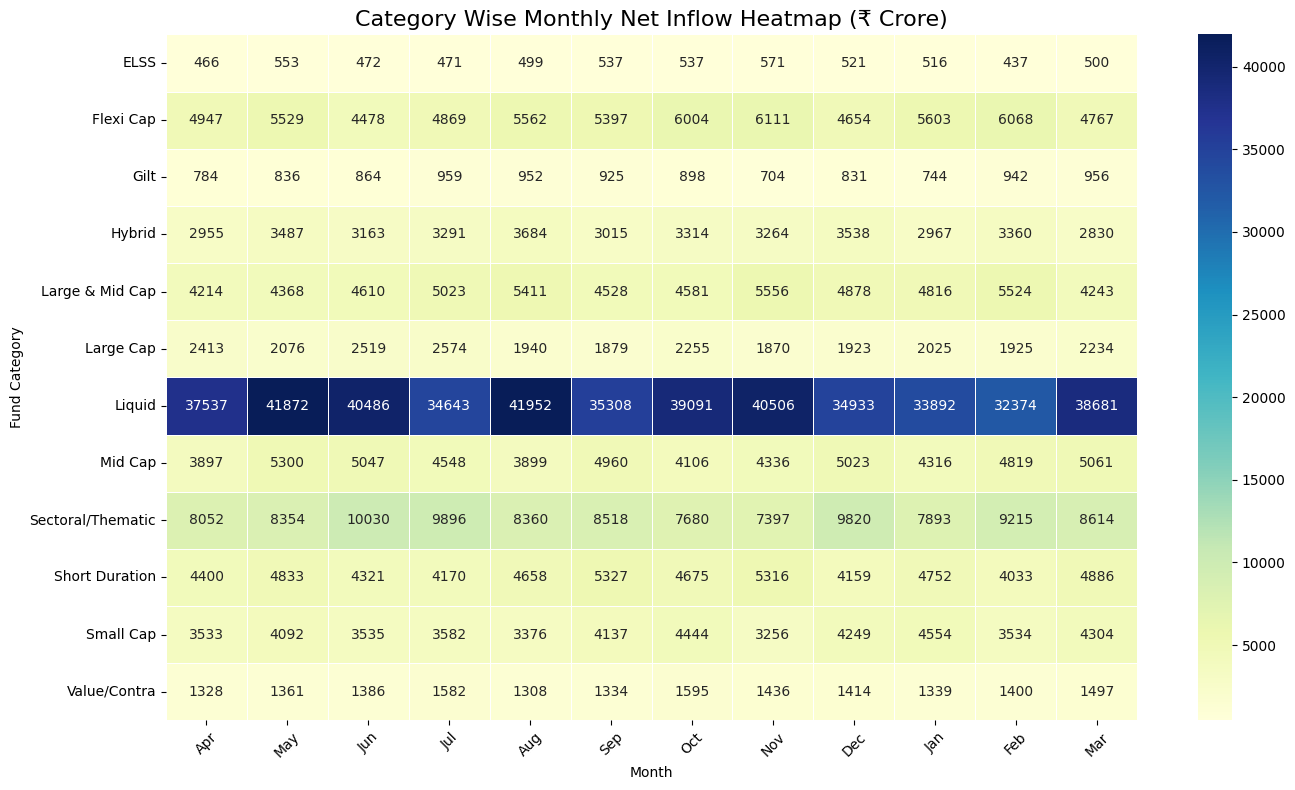

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Category Wise Monthly Net Inflow Heatmap (₹ Crore)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

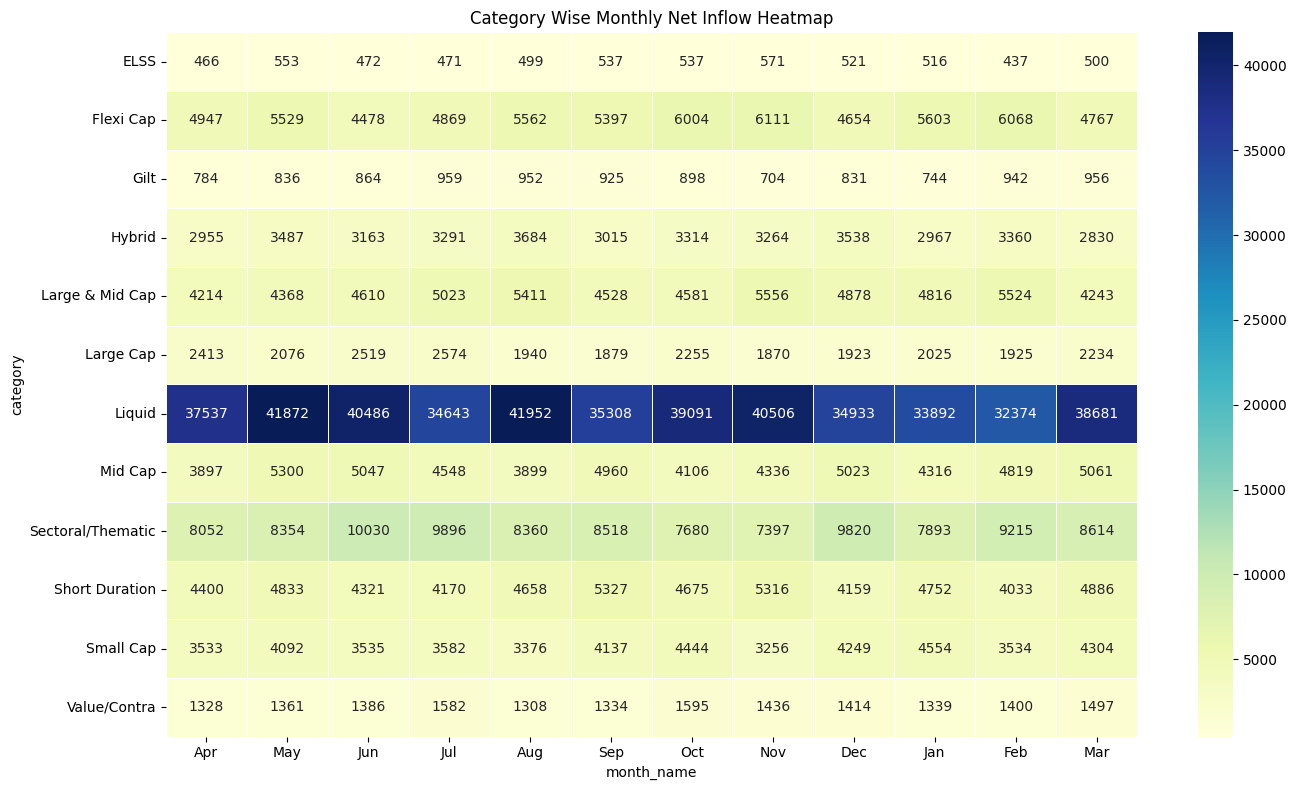

In [56]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category Wise Monthly Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "/content/reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
fig.write_html(
   "/content/reports/category_inflow_heatmap.html"
)

In [58]:
import pandas as pd

transactions = pd.read_csv(
    "/content/Cleaned_08_investor_transactions (1).csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


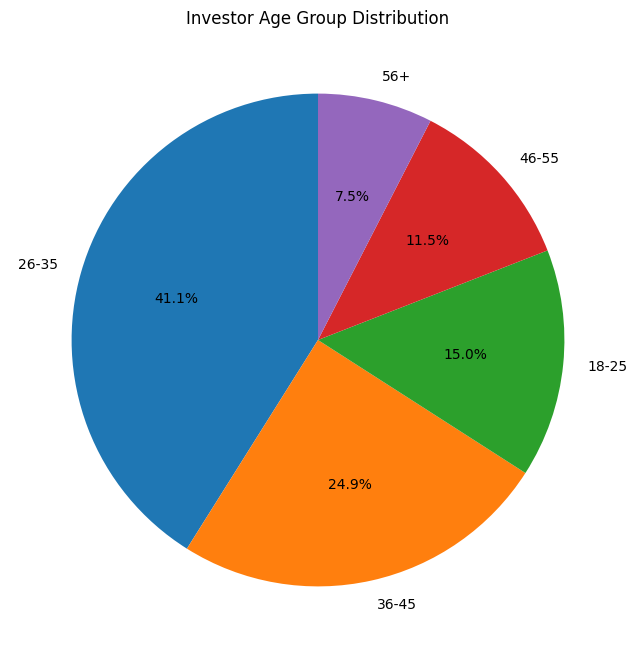

In [60]:
import matplotlib.pyplot as plt


age_distribution = (
    transactions['age_group']
    .value_counts()
)


plt.figure(figsize=(8,8))


plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)


plt.title(
    "Investor Age Group Distribution"
)


plt.show()

In [61]:
sip_data = transactions[
    transactions['transaction_type']
    .str.lower()
    .str.contains("sip")
]

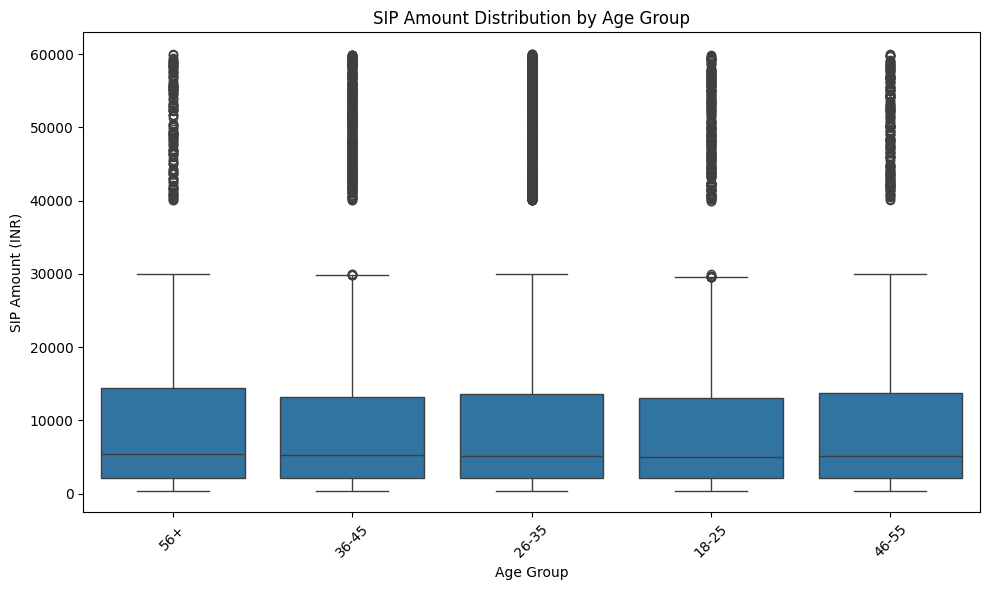

In [117]:
import os
import seaborn as sns
import matplotlib.pyplot as plt


# reports folder create
os.makedirs(
    "/content/reports",
    exist_ok=True
)


plt.figure(figsize=(10,6))


sns.boxplot(
    data=sip_data,
    x='age_group',
    y='amount_inr'
)


plt.title(
    "SIP Amount Distribution by Age Group"
)


plt.xlabel(
    "Age Group"
)


plt.ylabel(
    "SIP Amount (INR)"
)


plt.xticks(rotation=45)

plt.tight_layout()


plt.savefig(
    "/content/reports/sip_amount_distribution_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()

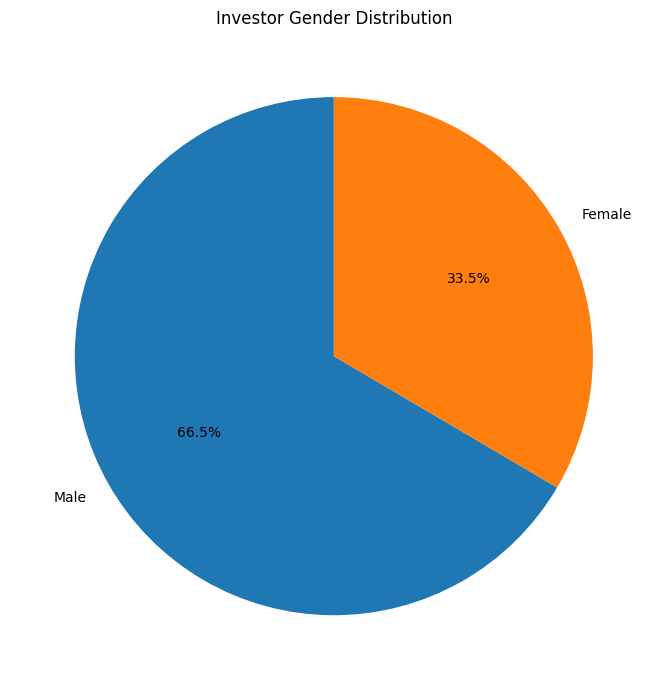

In [116]:
import os

# reports folder create
os.makedirs(
    "/content/reports",
    exist_ok=True
)


gender_distribution = (
    transactions['gender']
    .value_counts()
)


plt.figure(figsize=(7,7))


plt.pie(
    gender_distribution,
    labels=gender_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)


plt.title(
    "Investor Gender Distribution"
)


plt.tight_layout()


plt.savefig(
    "/content/reports/investor_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()

In [68]:
age_distribution = transactions['age_group'].value_counts()

print(age_distribution)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


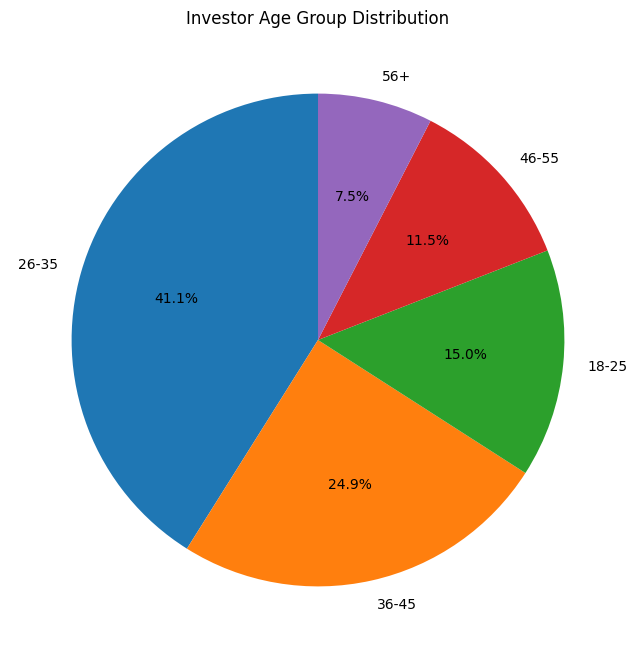

In [69]:
plt.figure(figsize=(8,8))

plt.pie(
    age_distribution.values,
    labels=age_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "/content/reports/investor_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
fig.write_html(
   "/content/reports/08_investor_transactions (1).html"
)

In [70]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [71]:
sip_data = transactions[
    transactions['transaction_type'].str.contains(
        'SIP',
        case=False,
        na=False
    )
]

In [72]:
state_sip = (
    sip_data
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

In [73]:
state_sip.head()

,amount_inr
state,
Maharashtra,16445629
Rajasthan,16544233
Delhi,17113608
West Bengal,17495769
Uttar Pradesh,17534858


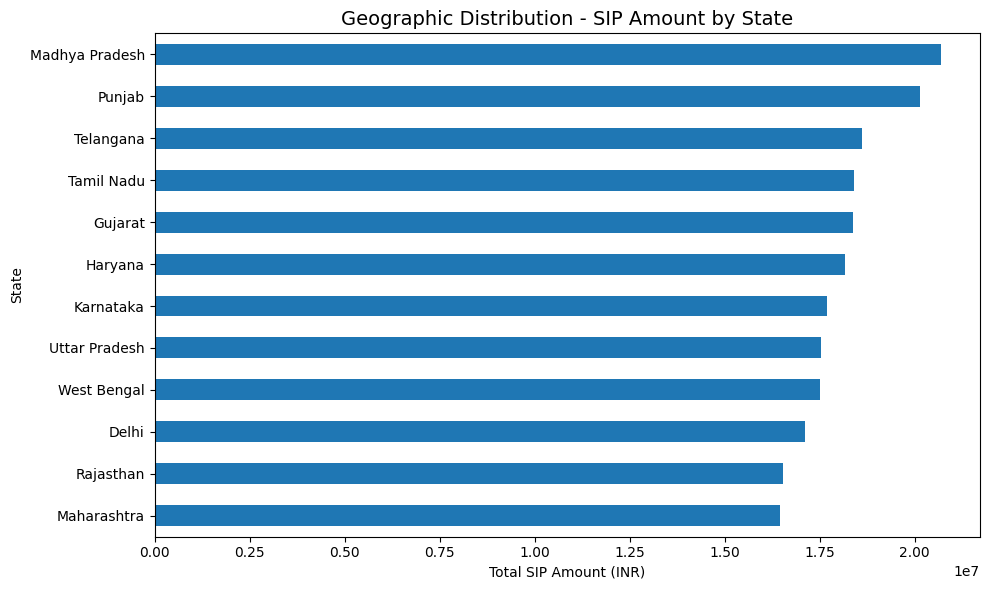

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

state_sip.plot(
    kind='barh'
)

plt.title(
    "Geographic Distribution - SIP Amount by State",
    fontsize=14
)

plt.xlabel(
    "Total SIP Amount (INR)"
)

plt.ylabel(
    "State"
)

plt.tight_layout()

plt.show()

In [75]:
transactions['city_tier'].value_counts()

,count
city_tier,
T30,21719
B30,11059


In [76]:
tier_count = (
    transactions['city_tier']
    .value_counts()
)

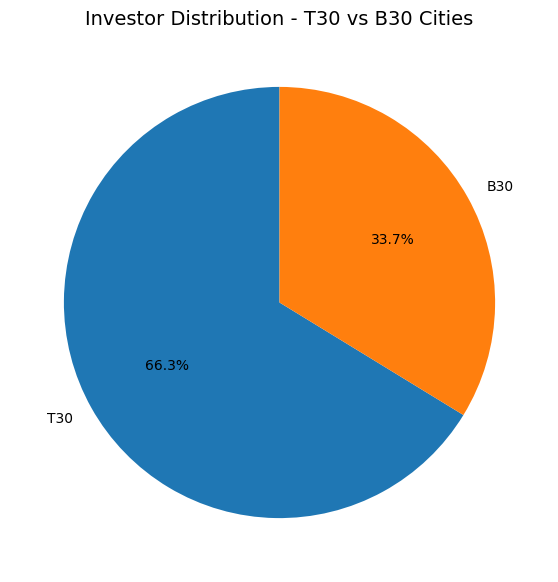

In [77]:
plt.figure(figsize=(7,7))

plt.pie(
    tier_count.values,
    labels=tier_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    "Investor Distribution - T30 vs B30 Cities",
    fontsize=14
)

plt.show()

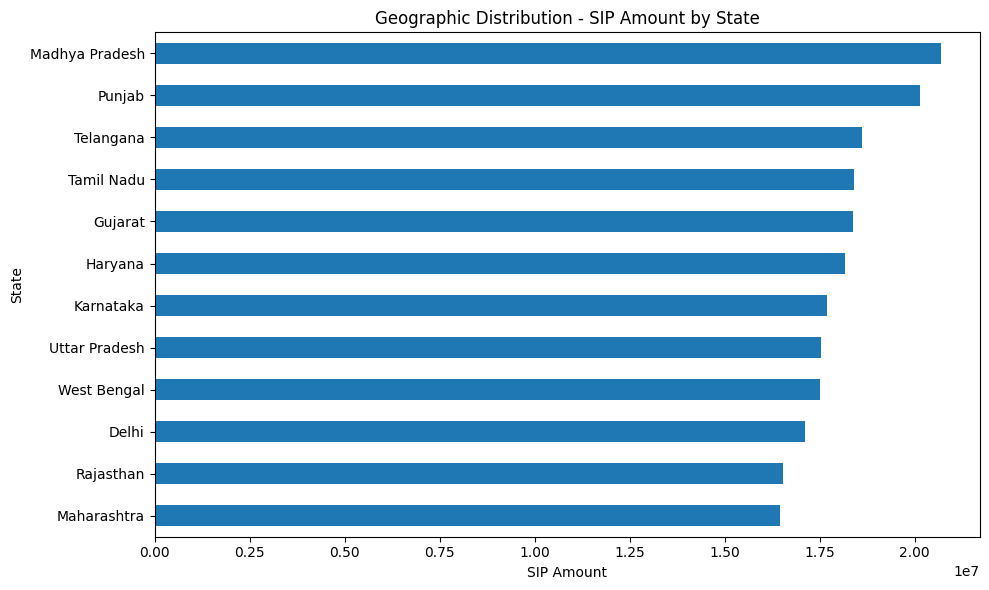

In [78]:
plt.figure(figsize=(10,6))

state_sip.plot(kind='barh')

plt.title("Geographic Distribution - SIP Amount by State")
plt.xlabel("SIP Amount")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "reports/sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

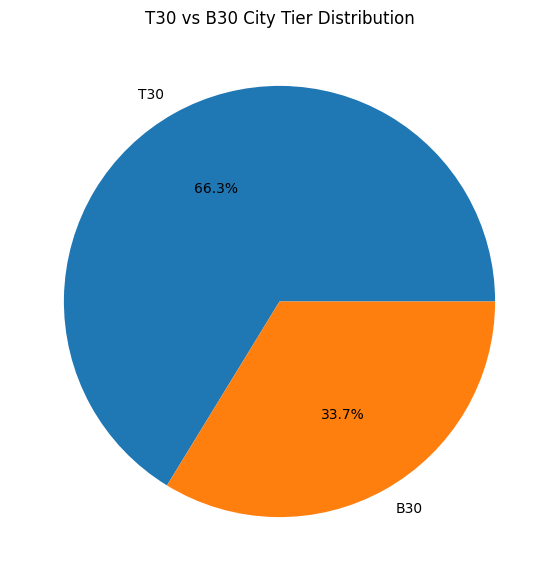

In [79]:
plt.figure(figsize=(7,7))

plt.pie(
    tier_count.values,
    labels=tier_count.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("/content/Cleaned_06_industry_folio_count (1).csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [83]:
folio['month'] = pd.to_datetime(folio['month'])

folio = folio.sort_values('month')

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [90]:
import numpy as np

# 5 key milestones automatically select
idx = np.linspace(0, len(folio)-1, 5, dtype=int)

milestones = folio.iloc[idx]

milestones

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
5,2023-04-01,15.54,10.88,2.18,0.93,1.55
10,2024-07-01,19.98,13.99,2.80,1.20,2.00
15,2025-04-01,23.89,16.72,3.34,1.43,2.39
20,2025-12-01,26.12,18.28,3.66,1.57,2.61


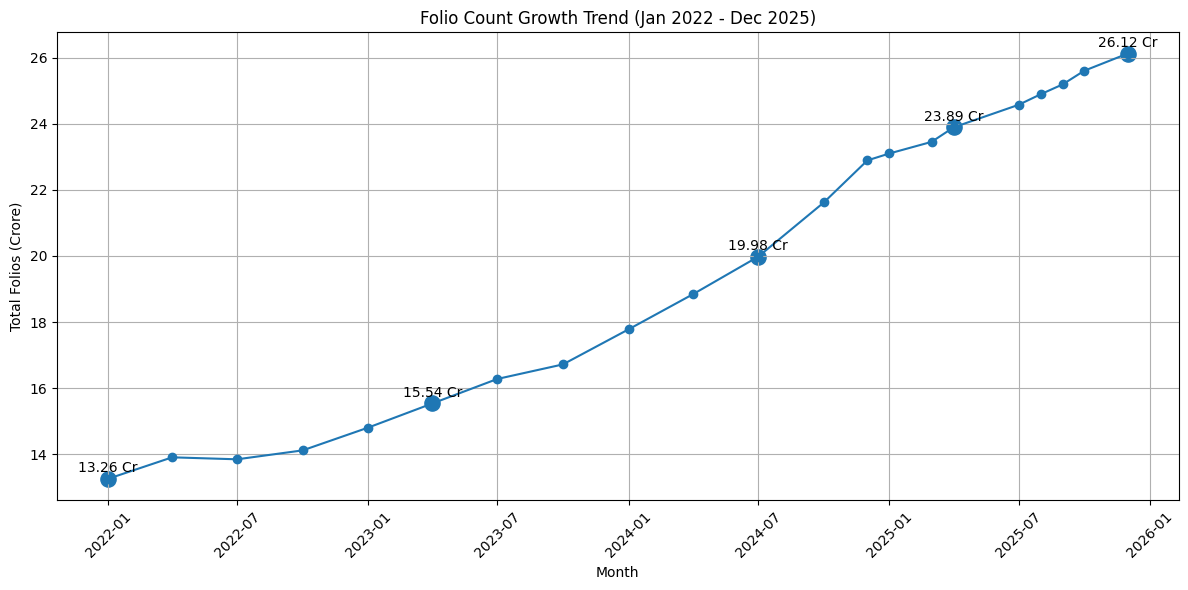

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.scatter(
    milestones['month'],
    milestones['total_folios_crore'],
    s=120
)

for x, y in zip(
    milestones['month'],
    milestones['total_folios_crore']
):
    plt.text(
        x,
        y + 0.2,
        f"{y:.2f} Cr",
        ha='center'
    )

plt.title("Folio Count Growth Trend (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()


# Pehle save karo
plt.savefig(
    "/content/reports/folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

# Fir show karo
plt.show()

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [95]:
nav = pd.read_csv(
    "/content/Cleaned_02_nav_history.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [97]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [98]:
nav["amfi_code"].unique()[:20]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093,
       119094, 119095, 119120, 119551])

In [99]:
selected_funds = nav["amfi_code"].unique()[:10]

In [100]:
return_matrix = (
    nav[
        nav["amfi_code"].isin(selected_funds)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="daily_return"
    )
)


return_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [101]:
return_matrix = return_matrix.dropna()

return_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360


In [102]:
return_matrix = return_matrix.dropna(
    how="all"
)

In [103]:
corr_matrix = return_matrix.corr(
    min_periods=30
)

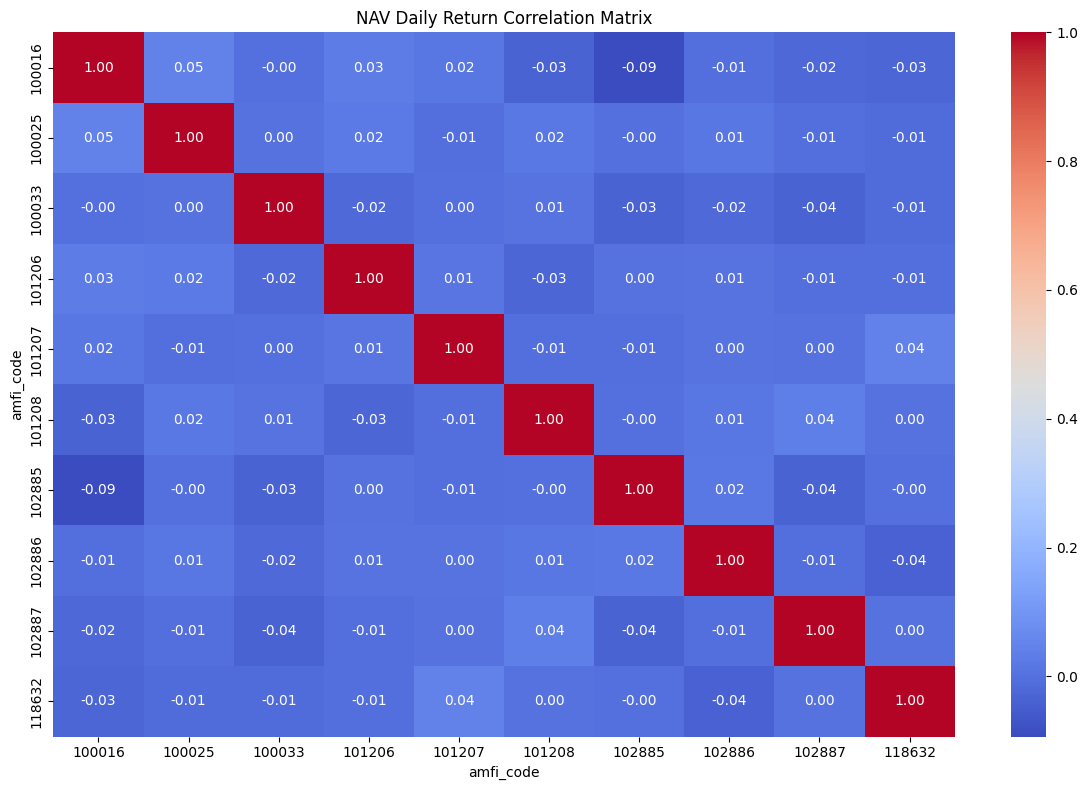

In [104]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NAV Daily Return Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "/content/reports/nav_return_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import os
holdings = pd.read_csv(
    "/content/Cleaned_09_portfolio_holidings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [109]:
equity_holdings = holdings.copy()

In [110]:
sector_allocation = (
    equity_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)


sector_allocation

,weight_pct
sector,
Banking,652.26
IT,455.47
Pharma,407.45
Automobile,323.65
Utilities,265.54
FMCG,229.11
Infrastructure,192.16
Diversified,169.23
Telecom,145.62


In [111]:
top_sectors = sector_allocation.head(8)


others = sector_allocation.iloc[8:].sum()


sector_chart = pd.concat(
    [
        top_sectors,
        pd.Series({"Others":others})
    ]
)


sector_chart

,0
Banking,652.26
IT,455.47
Pharma,407.45
Automobile,323.65
Utilities,265.54
FMCG,229.11
Infrastructure,192.16
Diversified,169.23
Others,705.12


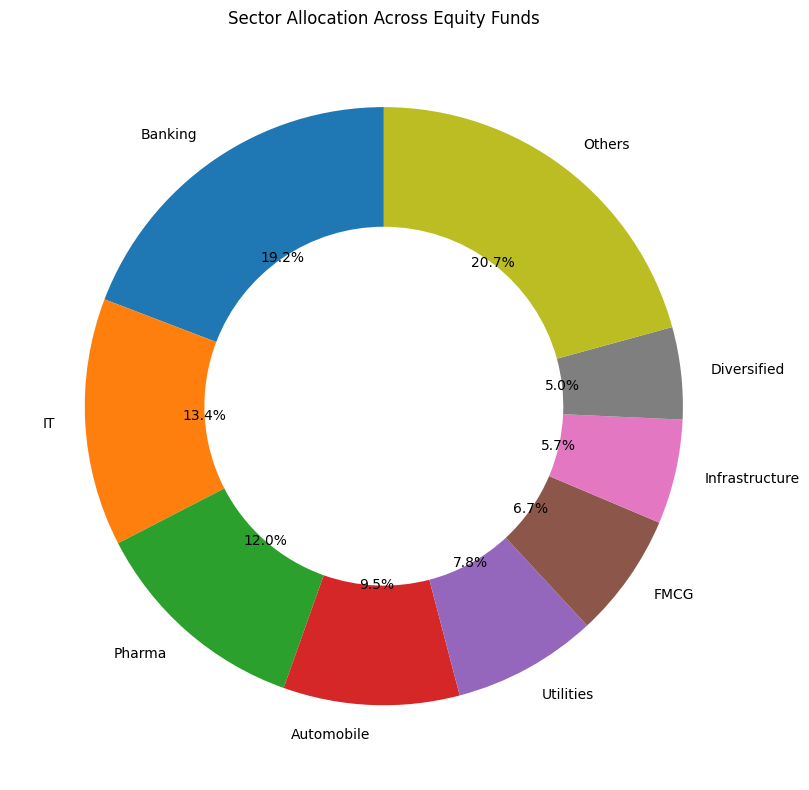

In [115]:
plt.figure(figsize=(10,8))

plt.pie(
    sector_chart.values,
    labels=sector_chart.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width":0.4
    }
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.savefig(
    "/content/reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Key EDA Findings

### 1. Folio Count Growth
The total industry folio count increased consistently from 13.26 Cr in January 2022 to 26.12 Cr in December 2025, showing strong growth in mutual fund participation.
(Chart Reference: Folio Count Growth Line Chart)

---

### 2. Category-wise SIP Inflows
Equity-oriented categories contributed the highest SIP inflows, reflecting increasing investor preference towards long-term wealth creation through equities.
(Chart Reference: Category Inflows Analysis)

---

### 3. Investor Age Distribution
The 26-35 age group represents the largest investor segment, indicating strong participation from young investors.
(Chart Reference: Investor Demographics Age Group Pie Chart)

---

### 4. Geographic Distribution
Major states contribute a significant share of SIP investments, showing concentration of mutual fund adoption in financially developed regions.
(Chart Reference: SIP Amount by State Horizontal Bar Chart)

---

### 5. T30 vs B30 Distribution
T30 cities contribute a larger portion of investments compared to B30 cities, highlighting higher mutual fund penetration in urban areas.
(Chart Reference: T30 vs B30 City Tier Pie Chart)

---

### 6. NAV Return Correlation
Most selected funds show positive correlation in daily NAV returns, indicating similar market movement patterns among equity funds.
(Chart Reference: NAV Return Correlation Heatmap)

---

### 7. Sector Allocation
Financial Services and Technology sectors have the highest portfolio allocation across equity funds, showing preference towards these major economic sectors.
(Chart Reference: Sector Allocation Donut Chart)

---

### 8. Fund Performance Comparison
Funds with higher long-term returns demonstrate stronger wealth creation potential compared to lower-performing schemes.
(Chart Reference: Scheme Performance Analysis)

---

### 9. AUM Distribution
A few major fund houses manage a significant portion of total assets under management, indicating concentration among leading AMCs.
(Chart Reference: AUM by Fund House Chart)

---

### 10. Risk and Return Relationship
Funds with higher returns generally exhibit higher volatility, demonstrating the relationship between risk and expected performance.
(Chart Reference: Risk-Return Analysis Chart)